# Phase 1C: event-anchored Close diagnostics

This notebook uses **Metrica Sample Game 1 only**. Events generate enriched candidate windows first; tracking geometry is inspected second. Tackles are high-precision, low-recall candidate generators—not definitions of Close—and many closing actions do not end in tackles. Completed-pass receptions are broader, noisier anchors. Neither event stream nor tracking geometry provides tactical ground truth.

No states, classifier, threshold, score, HMM, machine-learning model, smoothing, velocity, derivative, or general close-detection pipeline is introduced.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
DATA=ROOT/'data'/'metrica_sample_game_1'
HOME_PATH=DATA/'Sample_Game_1_RawTrackingData_Home_Team.csv'
AWAY_PATH=DATA/'Sample_Game_1_RawTrackingData_Away_Team.csv'
EVENT_PATH=DATA/'Sample_Game_1_RawEventsData.csv'
def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
pd.DataFrame({'file':[p.name for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)],'sha256':[sha256(p) for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)]})

,file,sha256
0,Sample_Game_1_RawTrackingData_Home_Team.csv,0a3d0eff7785950379c587d3597b86a2d91c2492281b46...
1,Sample_Game_1_RawTrackingData_Away_Team.csv,0a3df68a92af0290ede472e62de3b6489ddee29223da09...
2,Sample_Game_1_RawEventsData.csv,097dda6345e17390dca095331458fd00e47960c480c76f...


In [2]:
def load_tracking(path,team):
    header=pd.read_csv(path,header=None,nrows=3)
    players=[str(int(float(v))) for v in header.iloc[1,3:-2:2] if pd.notna(v)]
    columns=['Period','Frame','Time [s]']
    for p in players: columns += [f'{team}_{p}_x',f'{team}_{p}_y']
    columns += [f'{team}_ball_x',f'{team}_ball_y']
    return pd.read_csv(path,skiprows=3,names=columns),players
home,home_players=load_tracking(HOME_PATH,'Home'); away,away_players=load_tracking(AWAY_PATH,'Away')
events=pd.read_csv(EVENT_PATH)
tracking={'Home':home,'Away':away}; players={'Home':home_players,'Away':away_players}; opponent={'Home':'Away','Away':'Home'}
goalkeeper={'Home':'11','Away':'25'}  # manual match-specific exclusions retained from Phase 0/1A
home.shape,away.shape,events.shape

((145006, 33), (145006, 33), (1745, 14))

## Candidate definitions fixed before geometry

**Tackle anchors.** Retain only an opposing-team `TACKLE-WON` / `TACKLE-LOST` pair in the same period whose timestamps differ by at most 0.08 s and for which the pairing is unique. The winner is used as the focal defender and the loser as the opposing player. The window is −3 to +2 s around the winning-tackle timestamp. The 0.08 s allowance reconciles adjacent event rows; it is not a Close threshold.

**Reception anchors.** Retain event rows recorded as `PASS` with a nonmissing receiver (`To`), excluding explicit goal kicks and clearances. The pass endpoint is the reception anchor. At that frame, retain the two closest active opposing outfield players in raw coordinate space as separate candidate pairs. This rank-based shortlist has no distance cutoff and does **not** assume either defender closes. The window is −1 to +3 s. Keeping two defenders exposes rather than resolves plausible multi-defender cases.

A candidate is usable only when focal defender, attacker, and leave-one-out centroid coordinates exist at the window start, nearest anchor frame, and window end. Candidate membership and the chronological visual samples are fixed before endpoint-change summaries are calculated.

In [3]:
def pid(value): return str(value).replace('Player','')
def geometry(def_team,defender,att_team,attacker,period,anchor,pre,post):
    d=tracking[def_team]; a=tracking[att_team]
    w=d[(d.Period==period)&d['Time [s]'].between(anchor-pre,anchor+post)].copy()
    acols=['Frame',f'{att_team}_{attacker}_x',f'{att_team}_{attacker}_y']
    w=w.merge(a[acols],on='Frame',how='left',validate='one_to_one')
    refs=[p for p in players[def_team] if p not in {defender,goalkeeper[def_team]} and w[f'{def_team}_{p}_x'].notna().any()]
    w['centroid_x']=w[[f'{def_team}_{p}_x' for p in refs]].mean(axis=1)
    w['centroid_y']=w[[f'{def_team}_{p}_y' for p in refs]].mean(axis=1)
    w['da_x']=w[f'{def_team}_{defender}_x']-w[f'{att_team}_{attacker}_x']
    w['da_y']=w[f'{def_team}_{defender}_y']-w[f'{att_team}_{attacker}_y']
    w['distance']=np.sqrt(w.da_x**2+w.da_y**2)
    w['centroid_relative_x']=w[f'{def_team}_{defender}_x']-w.centroid_x
    w['centroid_relative_y']=w[f'{def_team}_{defender}_y']-w.centroid_y
    anchor_i=(w['Time [s]']-anchor).abs().idxmin() if len(w) else None
    checkpoints=[w.index[0],anchor_i,w.index[-1]] if len(w) else []
    required=['da_x','da_y','distance','centroid_relative_x','centroid_relative_y']
    usable=bool(len(w) and w.loc[checkpoints,required].notna().all().all())
    return w,refs,anchor_i,usable

tackle_rows=events[(events.Type=='CHALLENGE')&events.Subtype.isin(['TACKLE-WON','TACKLE-LOST'])].copy()
tackle_candidates=[]
for wi,winner in tackle_rows[tackle_rows.Subtype=='TACKLE-WON'].iterrows():
    matches=tackle_rows[(tackle_rows.Team!=winner.Team)&(tackle_rows.Subtype=='TACKLE-LOST')&(tackle_rows.Period==winner.Period)&((tackle_rows['Start Time [s]']-winner['Start Time [s]']).abs()<=0.08)]
    if len(matches)!=1: continue
    loser=matches.iloc[0]; d,a=pid(winner['From']),pid(loser['From'])
    g,refs,ai,usable=geometry(winner.Team,d,loser.Team,a,int(winner.Period),winner['Start Time [s]'],3,2)
    tackle_candidates.append({'event_index':wi,'period':int(winner.Period),'anchor':winner['Start Time [s]'],'def_team':winner.Team,'defender':d,'att_team':loser.Team,'attacker':a,'geometry':g,'refs':refs,'anchor_i':ai,'usable':usable})

excluded_pass_subtypes=['GOAL KICK','CLEARANCE','HEAD-CLEARANCE']
receptions=events[(events.Type=='PASS')&events.To.notna()&~events.Subtype.isin(excluded_pass_subtypes)].copy()
reception_candidates=[]
for ei,e in receptions.iterrows():
    att_team=e.Team; def_team=opponent[att_team]; attacker=pid(e.To); anchor=e['End Time [s]']; period=int(e.Period)
    dframe=tracking[def_team][(tracking[def_team].Period==period)&(tracking[def_team].Frame==e['End Frame'])]
    aframe=tracking[att_team][(tracking[att_team].Period==period)&(tracking[att_team].Frame==e['End Frame'])]
    if len(dframe)!=1 or len(aframe)!=1: continue
    ax,ay=aframe.iloc[0][[f'{att_team}_{attacker}_x',f'{att_team}_{attacker}_y']]
    ranked=[]
    for d in players[def_team]:
        if d==goalkeeper[def_team]: continue
        dx=dframe.iloc[0][f'{def_team}_{d}_x']-ax; dy=dframe.iloc[0][f'{def_team}_{d}_y']-ay
        if pd.notna(dx) and pd.notna(dy): ranked.append((np.sqrt(dx*dx+dy*dy),d))
    for rank,(_,d) in enumerate(sorted(ranked)[:2],start=1):
        g,refs,ai,usable=geometry(def_team,d,att_team,attacker,period,anchor,1,3)
        reception_candidates.append({'event_index':ei,'period':period,'anchor':anchor,'def_team':def_team,'defender':d,'att_team':att_team,'attacker':attacker,'nearby_rank':rank,'geometry':g,'refs':refs,'anchor_i':ai,'usable':usable})
len(tackle_candidates),len(reception_candidates)

(11, 1566)

## Candidate counts and descriptive endpoint changes

For auditability, “distance decreases” below means only that the later endpoint is numerically smaller than the earlier endpoint over the fixed interval: window start→anchor, anchor→window end, or full window. It uses no tolerance and is not a label, threshold, velocity, or close detector. It cannot show monotonicity or establish who caused convergence.

In [4]:
def summarize(candidates):
    rows=[]
    for c in candidates:
        if not c['usable']: continue
        g=c['geometry']; ai=c['anchor_i']; start=g.distance.iloc[0]; at=g.loc[ai,'distance']; end=g.distance.iloc[-1]
        rows.append({**{k:v for k,v in c.items() if k not in ['geometry','refs','anchor_i']},'start_distance':start,'anchor_distance':at,'end_distance':end,'pre_decrease':at<start,'post_decrease':end<at,'full_decrease':end<start,'ball_missing_in_window':g[f"{c['def_team']}_ball_x"].isna().any()})
    return pd.DataFrame(rows)
tackle_summary=summarize(tackle_candidates); reception_summary=summarize(reception_candidates)
count_report=pd.DataFrame([
 {'set':'tackle anchored','event anchors':len(tackle_candidates),'usable pair candidates':len(tackle_summary),'usable unique anchors':tackle_summary.event_index.nunique(),'pre-anchor endpoint decrease':int(tackle_summary.pre_decrease.sum()),'post-anchor endpoint decrease':int(tackle_summary.post_decrease.sum()),'full-window endpoint decrease':int(tackle_summary.full_decrease.sum())},
 {'set':'reception anchored','event anchors':len(receptions),'usable pair candidates':len(reception_summary),'usable unique anchors':reception_summary.event_index.nunique(),'pre-anchor endpoint decrease':int(reception_summary.pre_decrease.sum()),'post-anchor endpoint decrease':int(reception_summary.post_decrease.sum()),'full-window endpoint decrease':int(reception_summary.full_decrease.sum())}
])
count_report

,set,event anchors,usable pair candidates,usable unique anchors,pre-anchor endpoint decrease,post-anchor endpoint decrease,full-window endpoint decrease
0,tackle anchored,11,11,11,11,2,9
1,reception anchored,783,1566,783,1224,899,1031


In [5]:
limitations=pd.DataFrame({
 'item':['all tackle/challenge rows','tackle-won rows','uniquely paired tackle candidates','usable tackle pairs','completed-pass anchors retained','usable reception anchors','usable reception pair candidates','reception anchors with two usable defenders','usable windows with any missing defending-team ball x'],
 'count':[len(tackle_rows),int((tackle_rows.Subtype=='TACKLE-WON').sum()),len(tackle_candidates),len(tackle_summary),len(receptions),reception_summary.event_index.nunique(),len(reception_summary),int((reception_summary.groupby('event_index').size()>=2).sum()),int(tackle_summary.ball_missing_in_window.sum()+reception_summary.ball_missing_in_window.sum())]
})
limitations

,item,count
0,all tackle/challenge rows,66
1,tackle-won rows,37
2,uniquely paired tackle candidates,11
3,usable tackle pairs,11
4,completed-pass anchors retained,783
5,usable reception anchors,783
6,usable reception pair candidates,1566
7,reception anchors with two usable defenders,783
8,usable windows with any missing defending-team...,184


## Visual samples fixed by event order

The tackle sample is the first three usable paired tackles chronologically. The reception sample is the nearest-ranked candidate for the first three usable reception anchors after 60 s of match time. This deterministic event-order rule was fixed before inspecting geometry; no example was selected because its distance curve looked desirable.

In [6]:
tackle_sample=tackle_summary.sort_values(['period','anchor']).head(3)
reception_sample=(reception_summary[(reception_summary.anchor>=60)&(reception_summary.nearby_rank==1)].sort_values(['period','anchor']).drop_duplicates('event_index').head(3))
pd.concat([tackle_sample.assign(sample='tackle'),reception_sample.assign(sample='reception')],ignore_index=True)[['sample','period','anchor','def_team','defender','att_team','attacker']]

,sample,period,anchor,def_team,defender,att_team,attacker
0,tackle,1,225.08,Home,1,Away,18
1,tackle,1,553.76,Away,16,Home,9
2,tackle,1,1232.28,Away,19,Home,10
3,reception,1,87.36,Away,18,Home,10
4,reception,1,91.56,Away,22,Home,9
5,reception,1,148.12,Home,9,Away,21


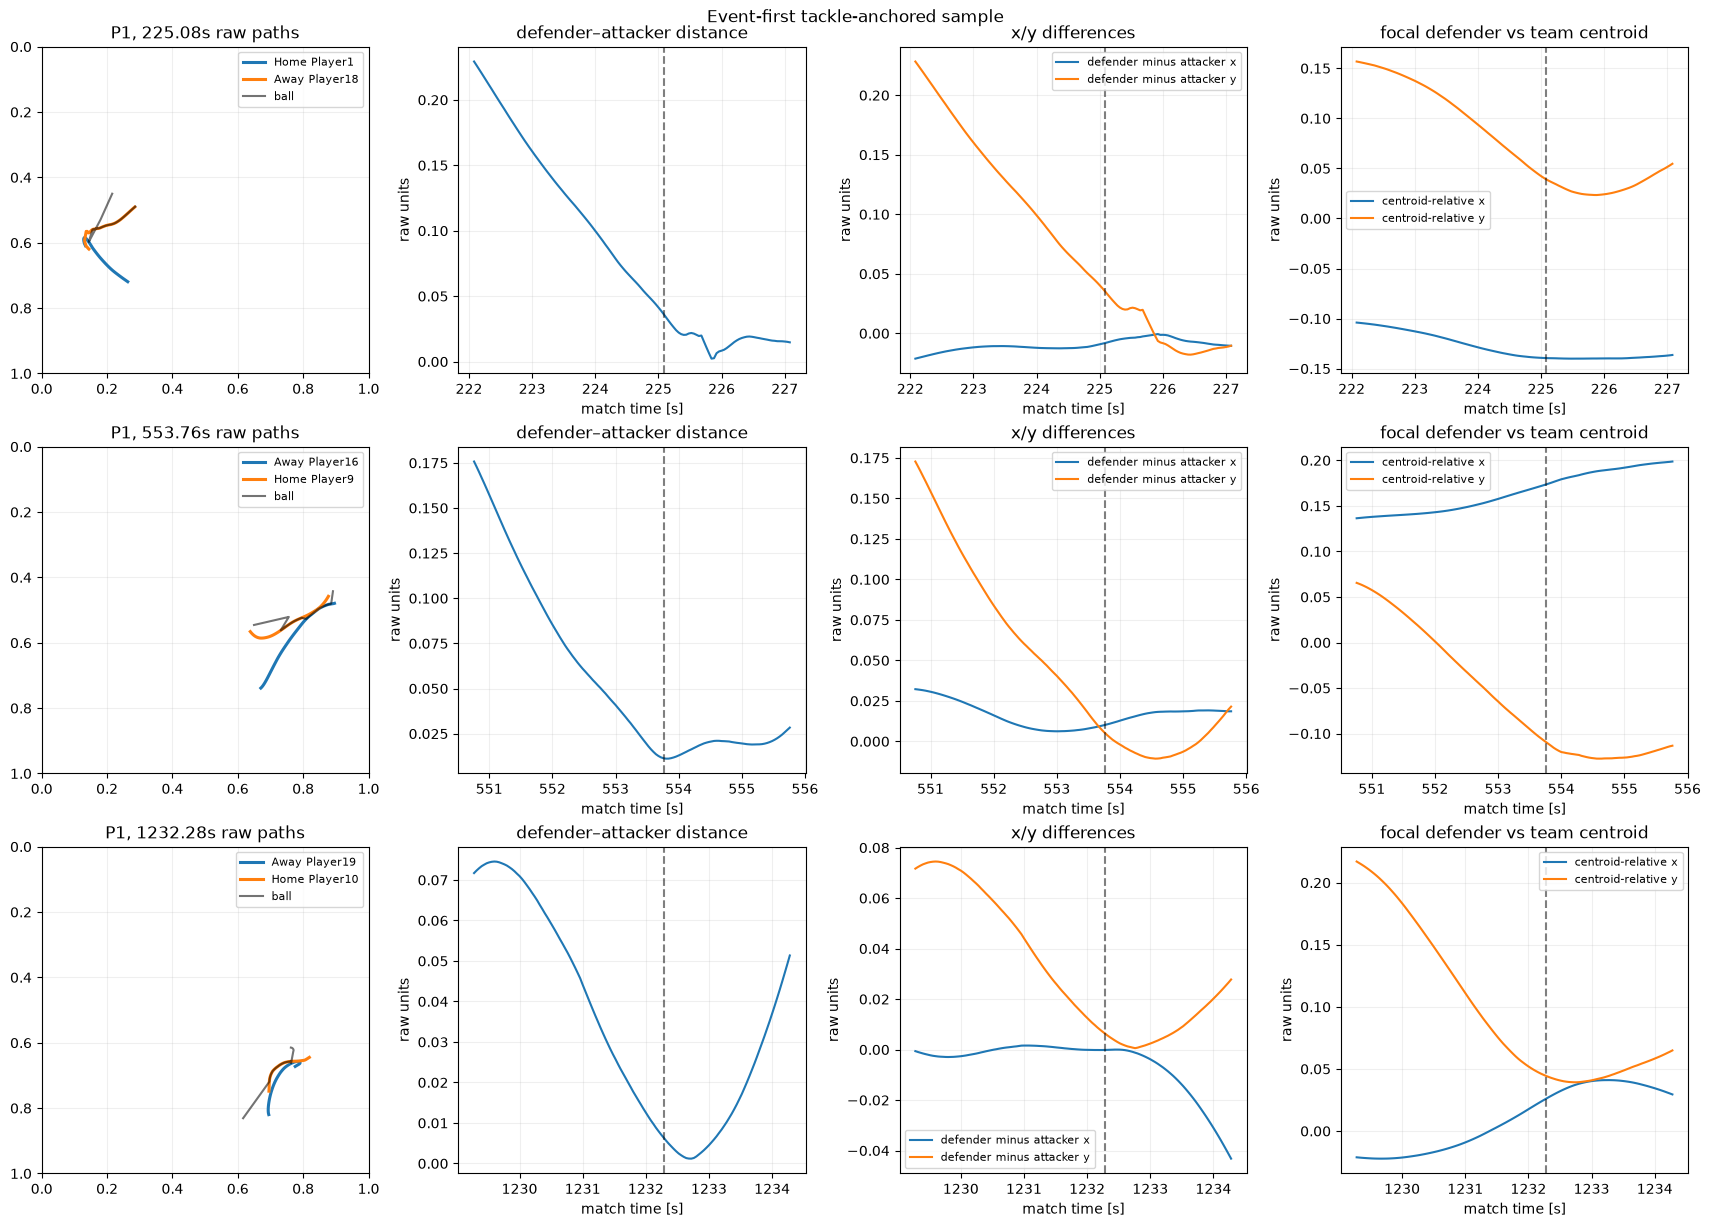

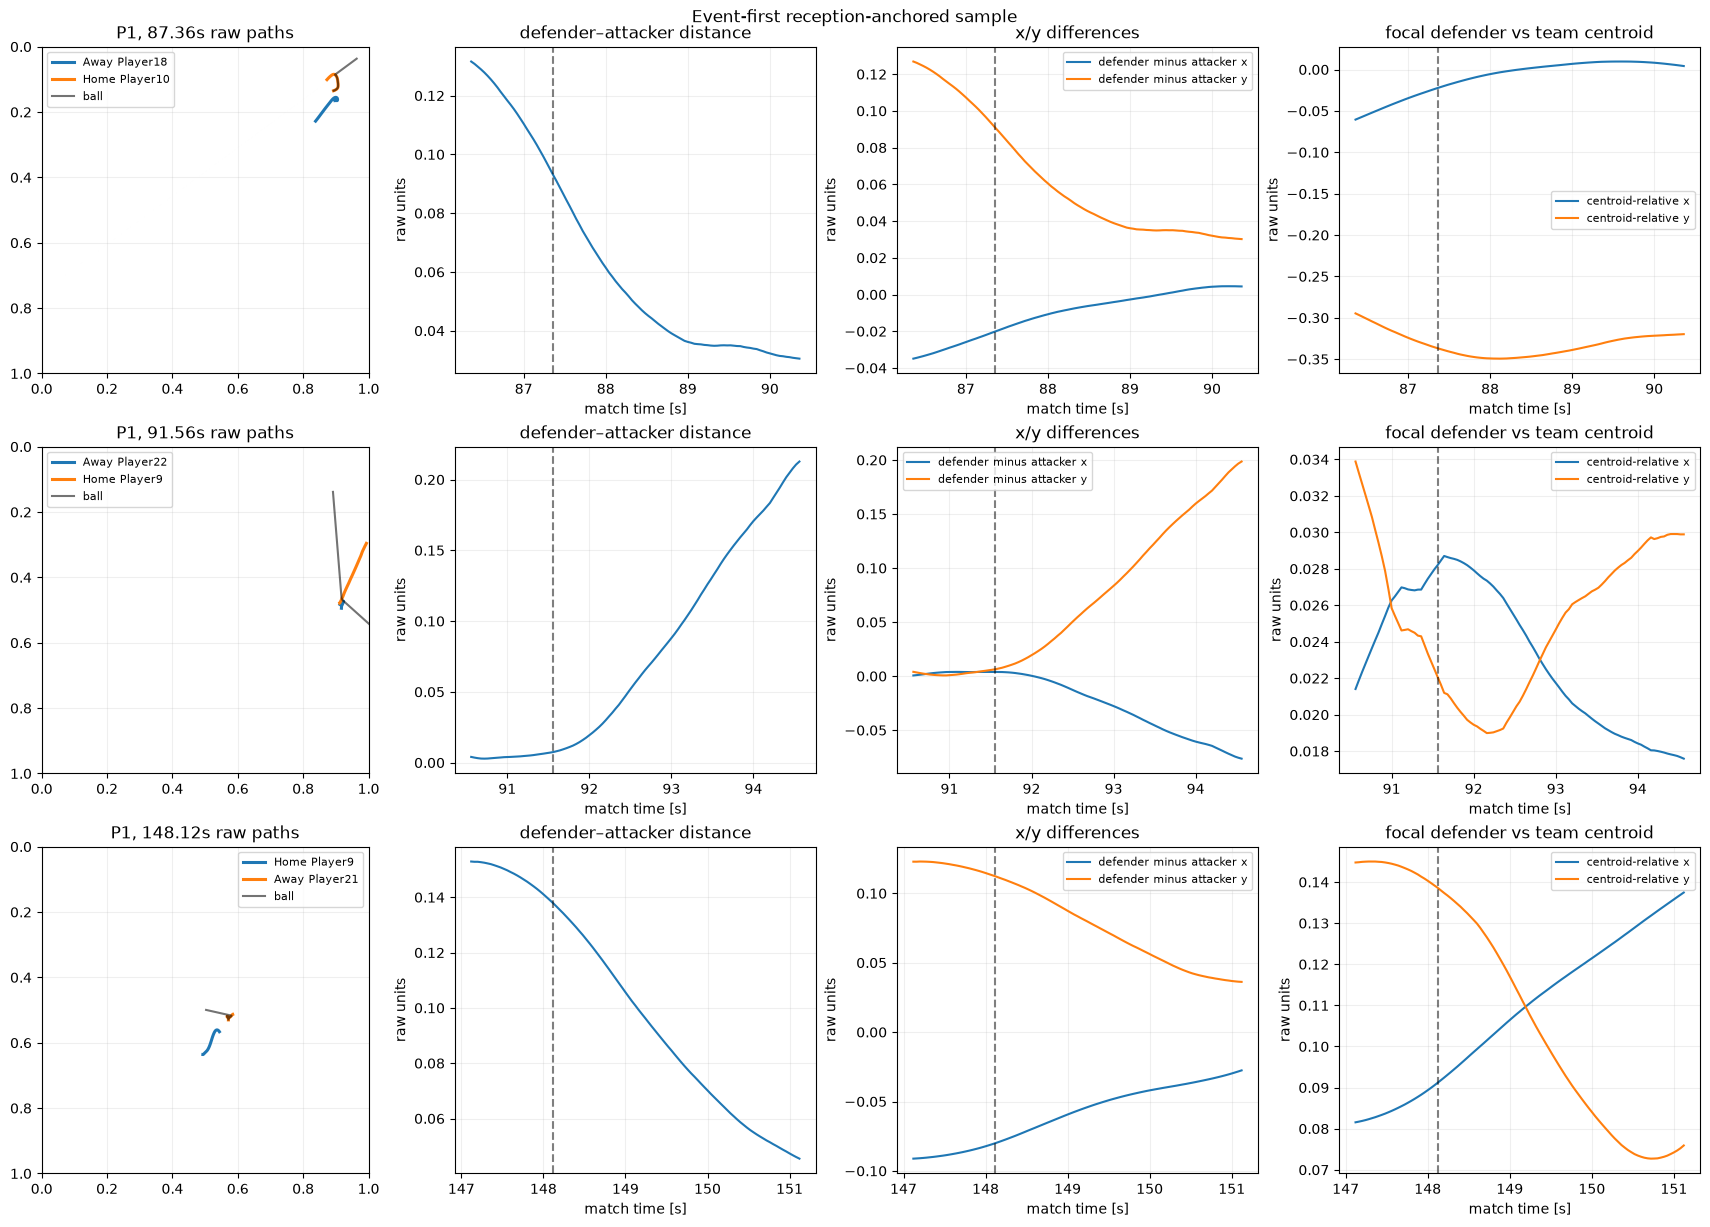

In [7]:
def candidate_by_event(candidates,event_index,defender): return next(c for c in candidates if c['event_index']==event_index and c['defender']==defender)
def plot_sample(summary,candidates,title):
    fig,axes=plt.subplots(len(summary),4,figsize=(17,4*len(summary)),constrained_layout=True)
    if len(summary)==1: axes=np.array([axes])
    for row,(_,s) in enumerate(summary.iterrows()):
        c=candidate_by_event(candidates,s.event_index,s.defender); g=c['geometry']; t=g['Time [s]']; anchor=c['anchor']; dt=c['def_team']; at=c['att_team']; d=c['defender']; a=c['attacker']
        ax=axes[row,0]; ax.plot(g[f'{dt}_{d}_x'],g[f'{dt}_{d}_y'],lw=2.2,label=f'{dt} Player{d}'); ax.plot(g[f'{at}_{a}_x'],g[f'{at}_{a}_y'],lw=2.2,label=f'{at} Player{a}'); ax.plot(g[f'{dt}_ball_x'],g[f'{dt}_ball_y'],color='black',alpha=.55,label='ball'); ax.set(xlim=(0,1),ylim=(1,0),aspect='equal',title=f'P{c["period"]}, {anchor:.2f}s raw paths'); ax.legend(fontsize=8); ax.grid(alpha=.2)
        ax=axes[row,1]; ax.plot(t,g.distance); ax.axvline(anchor,color='black',ls='--',alpha=.5); ax.set(title='defender–attacker distance',ylabel='raw units'); ax.grid(alpha=.2)
        ax=axes[row,2]; ax.plot(t,g.da_x,label='defender minus attacker x'); ax.plot(t,g.da_y,label='defender minus attacker y'); ax.axvline(anchor,color='black',ls='--',alpha=.5); ax.set(title='x/y differences',ylabel='raw units'); ax.legend(fontsize=8); ax.grid(alpha=.2)
        ax=axes[row,3]; ax.plot(t,g.centroid_relative_x,label='centroid-relative x'); ax.plot(t,g.centroid_relative_y,label='centroid-relative y'); ax.axvline(anchor,color='black',ls='--',alpha=.5); ax.set(title='focal defender vs team centroid',ylabel='raw units'); ax.legend(fontsize=8); ax.grid(alpha=.2)
        for ax in axes[row,1:]: ax.set_xlabel('match time [s]')
    fig.suptitle(title,y=1.01); plt.show()
plot_sample(tackle_sample,tackle_candidates,'Event-first tackle-anchored sample')
plot_sample(reception_sample,reception_candidates,'Event-first reception-anchored sample')

In [8]:
sample_audit=pd.concat([tackle_sample.assign(sample='tackle'),reception_sample.assign(sample='reception')],ignore_index=True)
sample_audit[['sample','period','anchor','def_team','defender','attacker','start_distance','anchor_distance','end_distance','pre_decrease','post_decrease','full_decrease']]

,sample,period,anchor,def_team,defender,attacker,start_distance,anchor_distance,end_distance,pre_decrease,post_decrease,full_decrease
0,tackle,1,225.08,Home,1,18,0.229297,0.036450,0.014729,True,True,True
1,tackle,1,553.76,Away,16,9,0.175749,0.011392,0.028365,True,False,True
2,tackle,1,1232.28,Away,19,10,0.071703,0.006412,0.051356,True,False,True
3,reception,1,87.36,Away,18,10,0.131595,0.092937,0.030510,True,True,True
4,reception,1,91.56,Away,22,9,0.004041,0.007474,0.212732,False,False,False
5,reception,1,148.12,Home,9,21,0.152922,0.137827,0.045493,True,True,True


## Diagnostic interpretation

The count table reports endpoint decreases, not “detected closes.” Across all 11 usable tackle pairs, start-to-anchor distance decreases, but only 2 decrease from anchor to window end—consistent with a tackle often marking contact or the end of an approach. Among 1,566 reception–defender pairs, 1,224 decrease before the anchor and 899 after it. These mixed results show that receptions enrich the search without defining Close. The sample audit above provides concrete event-eligible counterexamples wherever a decrease column is false.

The plots should be read for whether paths and separate x/y components make convergence soccer-legible, whether it occurs before or only after the anchor, and whether the focal defender also departs from or moves with the team centroid. An endpoint non-decrease can occur because a defender holds a line, blocks a lane, arrives before the window, the receiver moves away, another defender engages, or the anchor falls after decisive motion. A decrease can likewise be driven by attacker movement and is not automatically defender closing.

Tackle anchors are sparse because many tackle rows lack a unique paired opponent event; even a paired tackle can capture only contact or a last instant rather than the preceding approach. Conversely, many genuine closing behaviors never produce tackles. Reception anchors provide far more coverage but are noisy: receiving the ball does not imply pressure, nearest-at-anchor does not imply closing or responsibility, and two or more defenders can be equally plausible.

Ball coordinates are retained raw and their window-level missingness is reported; missing ball paths limit contextual interpretation but do not invalidate player geometry. Event-player identity is explicit for pass receiver and the conservatively paired tackles, but the event data does not identify tactical responsibility. Euclidean distance and nearest ranking use the source's nominally normalized axes, whose x/y dimensions are not metrically equivalent.

Events therefore help find informative windows but do not provide tactical ground truth. This event-anchored section stops at candidate counts, descriptive endpoint comparisons, and a fixed event-first visual audit. It does not create a Close score or detection pipeline.

# Phase 1C continuation: narrow kinematic decomposition

Candidate membership remains fixed: the 11 existing tackle-anchored pairs and the existing 91.56 s reception counterexample (Away Player22 / Home Player9). No new examples are searched.

Raw Metrica coordinates are converted before velocity calculation using a documented 105 × 68 m pitch: `x_m = 105 x_raw`, `y_m = 68 y_raw`. Positions are smoothed with a centered rolling mean; the primary window is 7 frames (0.28 s at 25 Hz), with 5- and 9-frame sensitivity calculations. `min_periods` equals the full window, so edges and any window containing a missing coordinate remain missing. No interpolation is performed. Velocities and distance closure use centered two-frame finite differences on smoothed values, `(z[t+1] - z[t-1]) / (2/25)`, adding one missing sample at each valid-run edge.

Let `u_da` point from defender to attacker. Positive defender approach is `v_d · u_da`; positive attacker approach is `v_a · (-u_da)`; positive closure rate is `-dD_da/dt`. The centroid and defender-residual velocities are projected on the same `u_da`, making `defender approach = collective component + residual approach` an exact vector decomposition up to floating-point error. Positive residual approach is behavior consistent with individualized closing, not proof of responsibility or intent.

In [9]:
PITCH_LENGTH_M=105.0; PITCH_WIDTH_M=68.0; DT=1/25
def centered_velocity(s): return (s.shift(-1)-s.shift(1))/(2*DT)
def kinematics(candidate,rolling_frames=7):
    g=candidate['geometry'].copy(); dt,at=candidate['def_team'],candidate['att_team']; d,a=candidate['defender'],candidate['attacker']
    raw={'d_x':g[f'{dt}_{d}_x']*PITCH_LENGTH_M,'d_y':g[f'{dt}_{d}_y']*PITCH_WIDTH_M,'a_x':g[f'{at}_{a}_x']*PITCH_LENGTH_M,'a_y':g[f'{at}_{a}_y']*PITCH_WIDTH_M,'c_x':g.centroid_x*PITCH_LENGTH_M,'c_y':g.centroid_y*PITCH_WIDTH_M}
    k=pd.DataFrame({'Time [s]':g['Time [s]']})
    for name,s in raw.items(): k[name]=s.rolling(rolling_frames,center=True,min_periods=rolling_frames).mean()
    rx=k.a_x-k.d_x; ry=k.a_y-k.d_y; k['distance_m']=np.sqrt(rx**2+ry**2); k['u_x']=rx/k.distance_m; k['u_y']=ry/k.distance_m
    for who in ['d','a','c']:
        k[f'v_{who}_x']=centered_velocity(k[f'{who}_x']); k[f'v_{who}_y']=centered_velocity(k[f'{who}_y'])
    k['defender_approach']=k.v_d_x*k.u_x+k.v_d_y*k.u_y
    k['attacker_approach']=-(k.v_a_x*k.u_x+k.v_a_y*k.u_y)
    k['closure_rate']=-centered_velocity(k.distance_m)
    k['centroid_approach']=k.v_c_x*k.u_x+k.v_c_y*k.u_y
    k['residual_approach']=(k.v_d_x-k.v_c_x)*k.u_x+(k.v_d_y-k.v_c_y)*k.u_y
    k['pair_identity_error']=k.closure_rate-(k.defender_approach+k.attacker_approach)
    k['collective_identity_error']=k.defender_approach-(k.centroid_approach+k.residual_approach)
    return k
tackle_fixed=[c for c in tackle_candidates if c['usable']]
reception_counterexample=next(c for c in reception_candidates if c['usable'] and abs(c['anchor']-91.56)<1e-9 and c['def_team']=='Away' and c['defender']=='22' and c['attacker']=='9')
len(tackle_fixed),{k:reception_counterexample[k] for k in ['period','anchor','def_team','defender','att_team','attacker']}

(11,
 {'period': 1,
  'anchor': 91.56,
  'def_team': 'Away',
  'defender': '22',
  'att_team': 'Home',
  'attacker': '9'})

In [10]:
def pre_anchor_summary(candidate,rolling_frames):
    k=kinematics(candidate,rolling_frames); pre=k[k['Time [s]']<candidate['anchor']]
    cols=['closure_rate','defender_approach','attacker_approach','centroid_approach','residual_approach']
    valid=pre[cols].dropna()
    return {'anchor':candidate['anchor'],'def_team':candidate['def_team'],'defender':candidate['defender'],'attacker':candidate['attacker'],'window_frames':rolling_frames,'valid_pre_frames':len(valid),**{f'mean_{c}':valid[c].mean() for c in cols},'mean_abs_pair_identity_error':k.pair_identity_error.abs().mean(),'max_abs_pair_identity_error':k.pair_identity_error.abs().max(),'max_abs_collective_identity_error':k.collective_identity_error.abs().max()}
sensitivity=pd.DataFrame([pre_anchor_summary(c,w) for w in [5,7,9] for c in tackle_fixed+[reception_counterexample]])
sensitivity.groupby('window_frames').agg(candidates=('anchor','size'),median_valid_pre_frames=('valid_pre_frames','median'),mean_pre_closure=('mean_closure_rate','mean'),mean_pre_defender=('mean_defender_approach','mean'),mean_pre_attacker=('mean_attacker_approach','mean'),mean_pre_centroid=('mean_centroid_approach','mean'),mean_pre_residual=('mean_residual_approach','mean'),mean_pair_identity_error=('mean_abs_pair_identity_error','mean'),max_pair_identity_error=('max_abs_pair_identity_error','max'),max_collective_identity_error=('max_abs_collective_identity_error','max'))

,candidates,median_valid_pre_frames,mean_pre_closure,mean_pre_defender,mean_pre_attacker,mean_pre_centroid,mean_pre_residual,mean_pair_identity_error,max_pair_identity_error,max_collective_identity_error
window_frames,,,,,,,,,,
5,12,72.0,1.745577,1.372603,0.372843,-0.051502,1.424105,0.006124,1.846455,1.776357e-15
7,12,71.0,1.737052,1.357498,0.379484,-0.046724,1.404222,0.005112,1.117164,1.776357e-15
9,12,70.0,1.733410,1.390866,0.342535,-0.043821,1.434687,0.003925,0.606786,8.881784e-16


In [11]:
primary=sensitivity[sensitivity.window_frames==7].copy()
primary['candidate']=primary.def_team+' Player'+primary.defender+' vs Player'+primary.attacker
primary[['anchor','candidate','mean_closure_rate','mean_defender_approach','mean_attacker_approach','mean_centroid_approach','mean_residual_approach','mean_abs_pair_identity_error','max_abs_pair_identity_error']].round(4)

,anchor,candidate,mean_closure_rate,mean_defender_approach,mean_attacker_approach,mean_centroid_approach,mean_residual_approach,mean_abs_pair_identity_error,max_abs_pair_identity_error
12,225.08,Home Player1 vs Player18,4.3367,2.0153,2.3214,-0.4523,2.4676,0.0221,1.1172
13,553.76,Away Player16 vs Player9,3.6540,2.9186,0.7360,-0.3909,3.3095,0.0014,0.0096
14,1232.28,Away Player19 vs Player10,1.5944,3.6026,-2.0082,-0.3684,3.9710,0.0007,0.0163
15,2049.00,Away Player20 vs Player9,0.0233,0.7635,-0.7402,-0.9014,1.6648,0.0140,0.7520
16,2184.16,Home Player8 vs Player23,1.4083,1.7898,-0.3829,-0.5105,2.3003,0.0110,0.1738
17,3682.88,Home Player8 vs Player15,2.2275,1.5491,0.6783,1.3425,0.2066,0.0028,0.0804
18,3838.96,Home Player3 vs Player23,1.2557,0.1362,1.1208,-0.8033,0.9395,0.0023,0.0389
19,4233.60,Home Player12 vs Player18,1.7587,-0.1168,1.8755,0.8079,-0.9247,0.0043,0.0841
20,4392.48,Home Player6 vs Player19,3.5347,2.3256,1.2092,0.1618,2.1638,0.0006,0.0042
21,5031.76,Home Player9 vs Player21,0.5558,2.3124,-1.7566,1.5218,0.7906,0.0001,0.0012


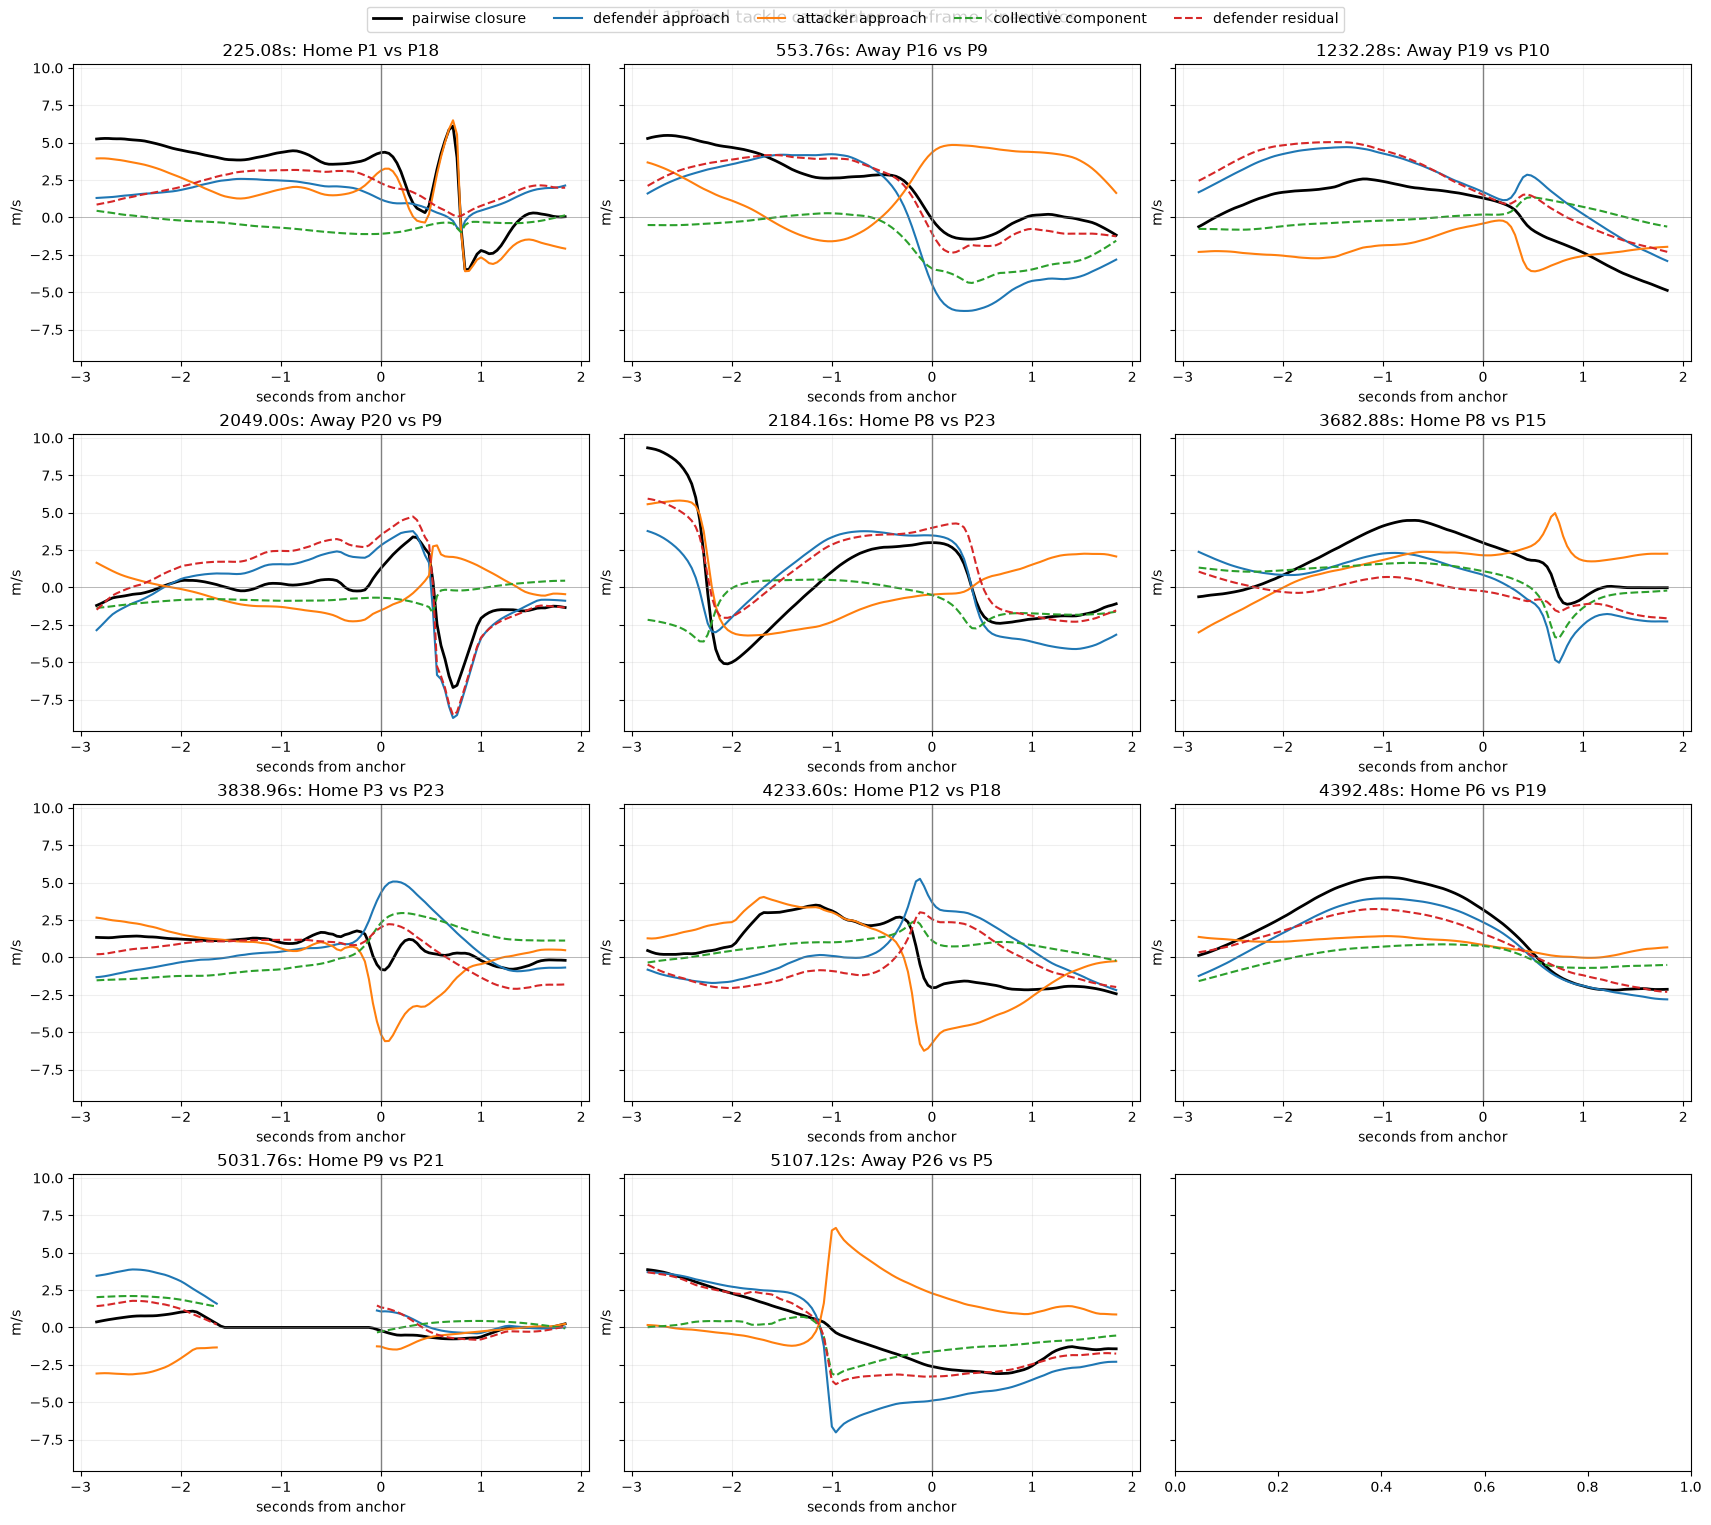

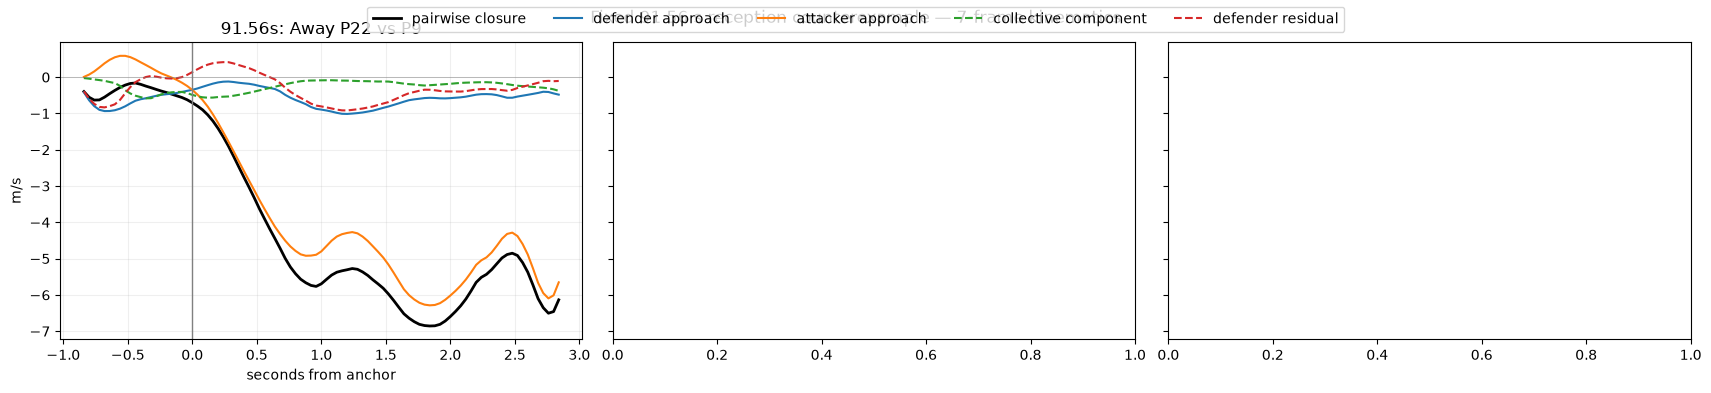

In [12]:
def plot_kinematics(candidates,title):
    n=len(candidates); fig,axes=plt.subplots((n+2)//3,3,figsize=(17,3.7*((n+2)//3)),sharey=True,constrained_layout=True); axes=np.atleast_1d(axes).flat
    for ax,c in zip(axes,candidates):
        k=kinematics(c,7); rel=k['Time [s]']-c['anchor']
        ax.plot(rel,k.closure_rate,label='pairwise closure',lw=2,color='black')
        ax.plot(rel,k.defender_approach,label='defender approach')
        ax.plot(rel,k.attacker_approach,label='attacker approach')
        ax.plot(rel,k.centroid_approach,label='collective component',ls='--')
        ax.plot(rel,k.residual_approach,label='defender residual',ls='--')
        ax.axvline(0,color='grey',lw=1); ax.axhline(0,color='grey',lw=.7,alpha=.5); ax.grid(alpha=.2)
        ax.set(title=f"{c['anchor']:.2f}s: {c['def_team']} P{c['defender']} vs P{c['attacker']}",xlabel='seconds from anchor',ylabel='m/s')
    for ax in list(axes)[n:]: ax.set_visible(False)
    handles,labels=fig.axes[0].get_legend_handles_labels(); fig.legend(handles,labels,loc='upper center',ncol=5); fig.suptitle(title,y=1.02); plt.show()
plot_kinematics(tackle_fixed,'All 11 fixed tackle candidates — 7-frame kinematics')
plot_kinematics([reception_counterexample],'Fixed 91.56 s reception counterexample — 7-frame kinematics')

## Kinematic interpretation and stopping point

The detailed table keeps four ideas separate: positive pairwise closure describes convergence; positive defender and attacker terms identify each player's instantaneous geometric contribution; the centroid term describes defensive collective translation along the same pair axis; and the residual term is the defender contribution beyond that translation. Negative values describe motion contributing to separation.

The pairwise identity check compares observed finite-difference distance closure with the sum of defender and attacker approach components. The collective identity check verifies that defender approach equals centroid plus residual approach. Remaining pairwise discrepancy is expected from evaluating a changing unit vector with finite differences after rolling-position smoothing; both mean absolute and conservative maximum discrepancies are reported. The largest instantaneous error occurs near a very small pair separation, where the unit direction can rotate rapidly.

With the primary 7-frame window, five tackle candidates have positive mean pre-anchor contributions from both defender and attacker; four combine positive defender approach with attacker motion contributing to separation; and two combine positive attacker approach with defender motion contributing to separation. Comparing the two signed player contributions arithmetically, the defender term is larger in seven tackle windows and the attacker term in four. These statements describe pairwise kinematics, not tactical categories.

Collective translation varies materially. At 3682.88 s, 1.3425 m/s of the defender's 1.5491 m/s mean approach lies in the centroid component; at 5031.76 s the corresponding values are 1.5218 and 2.3124 m/s. At 4233.60 s, convergence is attacker-driven on average while defender and residual components are negative. The fixed 91.56 s reception counterexample has mean closure −0.4030 m/s, defender approach −0.6411 m/s, attacker approach +0.2365 m/s, centroid component −0.3334 m/s, and residual −0.3077 m/s: the pair separates despite the event anchor.

The 5/7/9-frame sensitivity table shows similar aggregate mean contributions across all three minimal smoothing choices. No missing coordinates are interpolated, and no categorical tactical interpretation is assigned. Positive residual approach is only behavior consistent with individualized closing. This continuation stops after the fixed-candidate kinematic diagnostic and does not build a Close score or detector.